## K Nearest Neighbors 

The k-nearest neighbors (KNN) algorithm is a simple, easy-to-implement supervised machine learning algorithm that can be used in classification and regression problems.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('classified_data.txt', index_col=0)
df

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1
...,...,...,...,...,...,...,...,...,...,...,...
995,1.010953,1.034006,0.853116,0.622460,1.036610,0.586240,0.746811,0.319752,1.117340,1.348517,1
996,0.575529,0.955786,0.941835,0.792882,1.414277,1.269540,1.055928,0.713193,0.958684,1.663489,0
997,1.135470,0.982462,0.781905,0.916738,0.901031,0.884738,0.386802,0.389584,0.919191,1.385504,1
998,1.084894,0.861769,0.407158,0.665696,1.608612,0.943859,0.855806,1.061338,1.277456,1.188063,1


#### Standardize the variables

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
scaler = StandardScaler()

In [6]:
scaler.fit(df.drop('TARGET CLASS', axis=1))

,copy,True
,with_mean,True
,with_std,True


In [7]:
scaled_feat = scaler.transform(df.drop('TARGET CLASS', axis=1))

In [9]:
scaled_feat

array([[-0.12354188,  0.18590747, -0.91343069, ..., -1.48236813,
        -0.9497194 , -0.64331425],
       [-1.08483602, -0.43034845, -1.02531333, ..., -0.20224031,
        -1.82805088,  0.63675862],
       [-0.78870217,  0.33931821,  0.30151137, ...,  0.28570652,
        -0.68249379, -0.37784986],
       ...,
       [ 0.64177714, -0.51308341, -0.17920486, ..., -2.36249443,
        -0.81426092,  0.11159651],
       [ 0.46707241, -0.98278576, -1.46519359, ..., -0.03677699,
         0.40602453, -0.85567   ],
       [-0.38765353, -0.59589427, -1.4313981 , ..., -0.56778932,
         0.3369971 ,  0.01034996]], shape=(1000, 10))

In [8]:
df_feat = pd.DataFrame(scaled_feat, columns=df.columns[:-1])

In [10]:
df_feat

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510
...,...,...,...,...,...,...,...,...,...,...
995,0.211653,-0.312490,0.065163,-0.259834,0.017567,-1.395721,-0.849486,-2.604264,-0.139347,-0.069602
996,-1.292453,-0.616901,0.369613,0.482648,1.569891,1.273495,0.362784,-1.242110,-0.679746,1.473448
997,0.641777,-0.513083,-0.179205,1.022255,-0.539703,-0.229680,-2.261339,-2.362494,-0.814261,0.111597
998,0.467072,-0.982786,-1.465194,-0.071465,2.368666,0.001269,-0.422041,-0.036777,0.406025,-0.855670


#### Train test split

In [13]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(df_feat, df['TARGET CLASS'], train_size=0.33, random_state=42)

#### Using KNN

In [12]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
knn = KNeighborsClassifier(n_neighbors=1)

In [18]:
knn.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
pred = knn.predict(X_test)

#### Prediction and Eval

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

In [21]:
print(confusion_matrix(y_test, pred))

[[301  29]
 [ 25 315]]


In [22]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.91      0.92       330
           1       0.92      0.93      0.92       340

    accuracy                           0.92       670
   macro avg       0.92      0.92      0.92       670
weighted avg       0.92      0.92      0.92       670



#### Choose a K value

 * Elbow method

In [23]:
error_rate = []

for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

In [24]:
error_rate

[np.float64(0.08059701492537313),
 np.float64(0.09104477611940298),
 np.float64(0.07164179104477612),
 np.float64(0.07014925373134329),
 np.float64(0.07761194029850746),
 np.float64(0.07313432835820896),
 np.float64(0.07761194029850746),
 np.float64(0.06716417910447761),
 np.float64(0.07611940298507462),
 np.float64(0.07313432835820896),
 np.float64(0.07611940298507462),
 np.float64(0.07014925373134329),
 np.float64(0.07014925373134329),
 np.float64(0.06716417910447761),
 np.float64(0.06865671641791045),
 np.float64(0.05970149253731343),
 np.float64(0.06119402985074627),
 np.float64(0.0626865671641791),
 np.float64(0.06417910447761194),
 np.float64(0.06417910447761194),
 np.float64(0.07313432835820896),
 np.float64(0.06865671641791045),
 np.float64(0.06716417910447761),
 np.float64(0.0626865671641791),
 np.float64(0.06567164179104477),
 np.float64(0.0626865671641791),
 np.float64(0.06716417910447761),
 np.float64(0.06417910447761194),
 np.float64(0.06417910447761194),
 np.float64(0.064

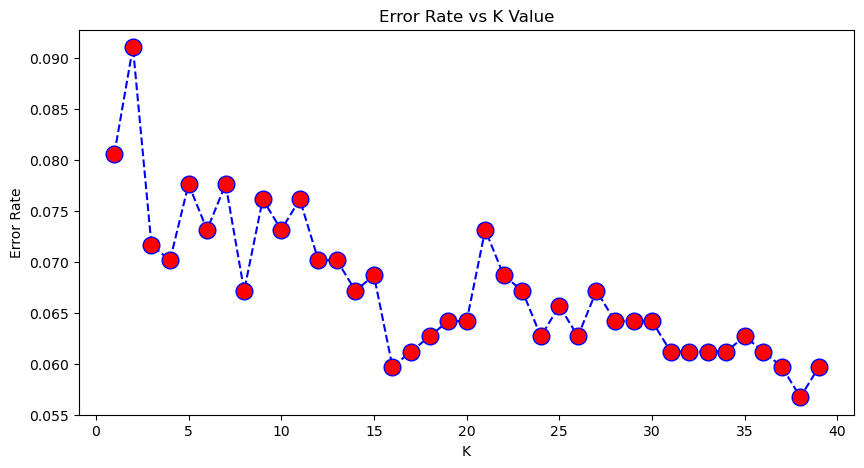

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 40), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=12)
plt.title("Error Rate vs K Value")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()

In [28]:
knn = KNeighborsClassifier(n_neighbors=12)
knn.fit(X_train, y_train)
pred_12 = knn.predict(X_test)
print(confusion_matrix(y_test, pred_12))

[[300  30]
 [ 17 323]]


In [29]:
print(classification_report(y_test, pred_12))

              precision    recall  f1-score   support

           0       0.95      0.91      0.93       330
           1       0.92      0.95      0.93       340

    accuracy                           0.93       670
   macro avg       0.93      0.93      0.93       670
weighted avg       0.93      0.93      0.93       670



In [30]:
knn = KNeighborsClassifier(n_neighbors=30)
knn.fit(X_train, y_train)
pred_30 = knn.predict(X_test)
print(confusion_matrix(y_test, pred_30))

[[301  29]
 [ 14 326]]


In [31]:
print(classification_report(y_test, pred_30))

              precision    recall  f1-score   support

           0       0.96      0.91      0.93       330
           1       0.92      0.96      0.94       340

    accuracy                           0.94       670
   macro avg       0.94      0.94      0.94       670
weighted avg       0.94      0.94      0.94       670

